In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as f1
from fastf1 import plotting
import mplcursors
from ing_theme_matplotlib import mpl_style
import mplcyberpunk

In [2]:
def convert_to_normal(time):
    if pd.isna(time):
        return time

    time_str = str(time)
    parts = time_str.split()

    days = int(parts[0])
    minutes, seconds_with_microseconds = parts[2].split(":")[1:]
    seconds, microseconds = seconds_with_microseconds.split(".")

    minutes = int(minutes)
    seconds = int(seconds)
    microseconds = int(microseconds)

    total_microseconds = (
        days * 86400000000 + minutes * 60000000 + seconds * 1000000 + microseconds
    )

    minutes, remaining_microseconds = divmod(total_microseconds, 60000000)
    seconds, microseconds = divmod(remaining_microseconds, 1000000)

    normal_time = f"{minutes:02d}:{seconds:02d}.{microseconds:06d}"
    return normal_time

## Quali

In [16]:
quali = f1.get_session(2026, "Australia", "Qualifying")
quali.load()

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            

In [22]:
quali.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
63,RUS,Mercedes,NaN,1.0,NaT,
12,ANT,Mercedes,NaN,2.0,NaT,
6,HAD,Red Bull Racing,NaN,3.0,NaT,
16,LEC,Ferrari,NaN,4.0,NaT,
81,PIA,McLaren,NaN,5.0,NaT,
1,NOR,McLaren,NaN,6.0,NaT,
44,HAM,Ferrari,NaN,7.0,NaT,
30,LAW,Racing Bulls,NaN,8.0,NaT,
41,LIN,Racing Bulls,NaN,9.0,NaT,
5,BOR,Audi,NaN,10.0,NaT,


In [23]:
quali_laps = quali.laps
quali_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:18:17.451000,RUS,63,0 days 00:01:51.876000,1.0,1.0,0 days 00:16:28.955000,NaT,0 days 00:00:41.997000,0 days 00:00:19.351000,...,True,Mercedes,0 days 00:16:28.955000,2026-03-07 05:03:47.667,1,NaN,False,,False,False
1,0 days 00:19:37.291000,RUS,63,0 days 00:01:19.840000,2.0,1.0,NaT,NaT,0 days 00:00:27.990000,0 days 00:00:17.599000,...,True,Mercedes,0 days 00:18:17.451000,2026-03-07 05:05:36.163,1,NaN,False,,False,True
2,0 days 00:21:38.860000,RUS,63,0 days 00:02:01.569000,3.0,1.0,NaT,0 days 00:21:24.695000,0 days 00:00:40.873000,0 days 00:00:22.025000,...,True,Mercedes,0 days 00:19:37.291000,2026-03-07 05:06:56.003,1,NaN,False,,False,False
3,0 days 00:32:02.050000,RUS,63,NaT,4.0,2.0,0 days 00:21:42.023000,0 days 00:23:38.517000,0 days 00:00:46.779000,0 days 00:00:22.489000,...,False,Mercedes,0 days 00:21:38.860000,2026-03-07 05:08:57.572,125,NaN,False,,False,False
4,0 days 00:33:52.363000,RUS,63,0 days 00:01:50.313000,5.0,3.0,0 days 00:32:12.182000,NaT,0 days 00:00:52.390000,0 days 00:00:19.564000,...,False,Mercedes,0 days 00:32:12.182000,2026-03-07 05:19:30.894,1,NaN,False,,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,0 days 00:37:40.830000,BOT,77,0 days 00:01:44.306000,6.0,3.0,0 days 00:35:58.814000,NaT,0 days 00:00:41.112000,0 days 00:00:20.231000,...,True,Cadillac,0 days 00:35:58.814000,2026-03-07 05:23:17.526,1,NaN,False,,False,False
349,0 days 00:39:04.074000,BOT,77,0 days 00:01:23.244000,7.0,3.0,NaT,NaT,0 days 00:00:29.198000,0 days 00:00:18.068000,...,True,Cadillac,0 days 00:37:40.830000,2026-03-07 05:24:59.542,1,NaN,False,,False,True
350,0 days 00:40:53.451000,BOT,77,NaT,8.0,3.0,NaT,0 days 00:40:53.451000,0 days 00:00:37.594000,0 days 00:00:24.343000,...,True,Cadillac,0 days 00:39:04.074000,2026-03-07 05:26:22.786,1,NaN,False,,False,False
351,0 days 00:22:51.416000,VER,3,0 days 00:01:42.025000,1.0,1.0,0 days 00:21:13.117000,NaT,0 days 00:00:41.429000,0 days 00:00:19.065000,...,True,Red Bull Racing,0 days 00:21:13.117000,2026-03-07 05:08:31.829,1,NaN,False,,False,False


In [25]:
rus_quali_laps = quali.laps.pick_driver("RUS")
rus_quali = rus_quali_laps.pick_fastest().LapTime
rus_quali_lap_time = rus_quali_laps["LapTime"]
rus_quali_sec1 = rus_quali_laps["Sector1Time"]
rus_quali_sec2 = rus_quali_laps["Sector2Time"]
rus_quali_sec3 = rus_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(rus_quali), "which was in Lap number" ,rus_quali_laps.pick_fastest().LapNumber)
rus_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:18.518000 which was in Lap number 21.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,0 days 00:01:51.876000,0 days 00:00:41.997000,0 days 00:00:19.351000,0 days 00:00:50.528000,263.0,287.0,273.0,199.0
1,0 days 00:01:19.840000,0 days 00:00:27.990000,0 days 00:00:17.599000,0 days 00:00:34.251000,265.0,278.0,294.0,292.0
2,0 days 00:02:01.569000,0 days 00:00:40.873000,0 days 00:00:22.025000,0 days 00:00:58.671000,222.0,283.0,NaN,201.0
3,NaT,0 days 00:00:46.779000,0 days 00:00:22.489000,NaT,230.0,284.0,NaN,129.0
4,0 days 00:01:50.313000,0 days 00:00:52.390000,0 days 00:00:19.564000,0 days 00:00:38.359000,246.0,284.0,279.0,136.0


In [26]:
fastest_lap_rus_quali = rus_quali_laps.pick_fastest()
tele_rus_quali = fastest_lap_rus_quali.get_telemetry().add_distance()
speed_rus_quali = tele_rus_quali.Speed
tele_rus_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,279.000000,7,10868.500006
3,279.000000,7,10873.000000
4,280.363642,7,10909.681975
5,288.545460,7,11129.772884
6,289.000000,7,11142.000000
...,...,...,...
564,297.000000,7,11410.000000
565,297.331941,7,11441.202480
566,297.457203,7,11452.977065
567,297.958247,7,11500.075205


In [27]:
had_quali_laps = quali.laps.pick_driver("HAD")
fastest_lap_had_quali = had_quali_laps.pick_fastest().LapTime
had_quali_lap_time = had_quali_laps["LapTime"]
had_quali_sec1 = had_quali_laps["Sector1Time"]
had_quali_sec2 = had_quali_laps["Sector2Time"]
had_quali_sec3 = had_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_had_quali), "which was in Lap number" ,had_quali_laps.pick_fastest().LapNumber)
had_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:19.303000 which was in Lap number 18.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
40,0 days 00:01:48.799000,0 days 00:00:41.250000,0 days 00:00:19.672000,0 days 00:00:47.877000,247.0,288.0,281.0,176.0
41,0 days 00:01:20.445000,0 days 00:00:28.200000,0 days 00:00:17.919000,0 days 00:00:34.326000,284.0,268.0,310.0,301.0
42,NaT,0 days 00:00:39.694000,0 days 00:00:24.509000,NaT,213.0,250.0,NaN,251.0
43,0 days 00:02:00.766000,0 days 00:00:49.159000,0 days 00:00:19.801000,0 days 00:00:51.806000,245.0,276.0,279.0,141.0
44,0 days 00:01:20.023000,0 days 00:00:28.076000,0 days 00:00:17.558000,0 days 00:00:34.389000,261.0,280.0,303.0,302.0


In [28]:
fastest_lap_had_quali = had_quali_laps.pick_fastest()
tele_had_quali = fastest_lap_had_quali.get_telemetry().add_distance()
speed_had_quali = tele_had_quali.Speed
tele_had_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,289.533333,7,11580.488889
3,290.500002,7,11609.166730
4,291.000000,7,11624.000000
5,291.000000,7,11624.000000
6,291.714286,7,11479.428571
...,...,...,...
576,305.000000,8,10914.000000
577,305.000000,8,10920.934157
578,305.000000,8,10942.000000
579,305.000000,8,10937.124979


In [29]:
lec_quali_laps = quali.laps.pick_driver("LEC")
fastest_lap_lec_quali = lec_quali_laps.pick_fastest().LapTime
lec_quali_lap_time = lec_quali_laps["LapTime"]
lec_quali_sec1 = lec_quali_laps["Sector1Time"]
lec_quali_sec2 = lec_quali_laps["Sector2Time"]
lec_quali_sec3 = lec_quali_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_lec_quali), "which was in Lap number" ,lec_quali_laps.pick_fastest().LapNumber)
lec_quali_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:19.327000 which was in Lap number 23.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
59,0 days 00:01:51.480000,0 days 00:00:43.936000,0 days 00:00:20.576000,0 days 00:00:46.968000,237.0,272.0,281.0,141.0
60,0 days 00:01:20.712000,0 days 00:00:28.361000,0 days 00:00:17.661000,0 days 00:00:34.690000,262.0,284.0,301.0,294.0
61,0 days 00:01:47.918000,0 days 00:00:36.526000,0 days 00:00:23.713000,0 days 00:00:47.679000,182.0,180.0,279.0,260.0
62,0 days 00:01:20.226000,0 days 00:00:28.211000,0 days 00:00:17.611000,0 days 00:00:34.404000,263.0,290.0,299.0,293.0
63,NaT,NaT,NaT,NaT,NaN,NaN,NaN,245.0


In [30]:
fastest_lap_lec_quali = lec_quali_laps.pick_fastest()
tele_lec_quali = fastest_lap_lec_quali.get_telemetry().add_distance()
speed_lec_quali = tele_lec_quali.Speed
tele_lec_quali.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
1,288.150003,7,11351.375104
2,289.000000,7,11379.000000
3,289.130436,7,11381.869588
4,290.000000,7,11401.000000
5,290.625000,7,11426.937500
...,...,...,...
574,300.000000,8,10497.000000
575,300.336100,8,10529.601711
576,301.000000,8,10594.000000
577,302.000000,8,10590.500000


In [31]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_quali_sec1),
        "Sector1Time": rus_quali_sec1,
        "Sector2Time": rus_quali_sec2,
        "Sector3Time": rus_quali_sec3,
        "Lap Time": rus_quali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_quali_sec1),
        "Sector1Time": lec_quali_sec1,
        "Sector2Time": lec_quali_sec2,
        "Sector3Time": lec_quali_sec3,
        "Lap Time": lec_quali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Issac Hadjar"] * len(had_quali_sec1),
        "Sector1Time": had_quali_sec1,
        "Sector2Time": had_quali_sec2,
        "Sector3Time": had_quali_sec3,
        "Lap Time": had_quali_lap_time,
    }
)



all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
0,George Russell,0 days 00:00:41.997000,0 days 00:00:19.351000,0 days 00:00:50.528000,0 days 00:01:51.876000
1,George Russell,0 days 00:00:27.990000,0 days 00:00:17.599000,0 days 00:00:34.251000,0 days 00:01:19.840000
2,George Russell,0 days 00:00:40.873000,0 days 00:00:22.025000,0 days 00:00:58.671000,0 days 00:02:01.569000
4,George Russell,0 days 00:00:52.390000,0 days 00:00:19.564000,0 days 00:00:38.359000,0 days 00:01:50.313000
5,George Russell,0 days 00:00:31.116000,0 days 00:00:23.100000,0 days 00:00:39.030000,0 days 00:01:33.246000
6,George Russell,0 days 00:00:27.908000,0 days 00:00:17.413000,0 days 00:00:34.186000,0 days 00:01:19.507000
8,George Russell,0 days 00:01:01.667000,0 days 00:00:23.062000,0 days 00:00:54.519000,0 days 00:02:19.248000
9,George Russell,0 days 00:00:27.816000,0 days 00:00:17.287000,0 days 00:00:33.831000,0 days 00:01:18.934000
11,George Russell,0 days 00:00:48.833000,0 days 00:00:20.916000,0 days 00:00:38.905000,0 days 00:01:48.654000
12,George Russell,0 days 00:00:27.662000,0 days 00:00:17.426000,0 days 00:00:33.899000,0 days 00:01:18.987000


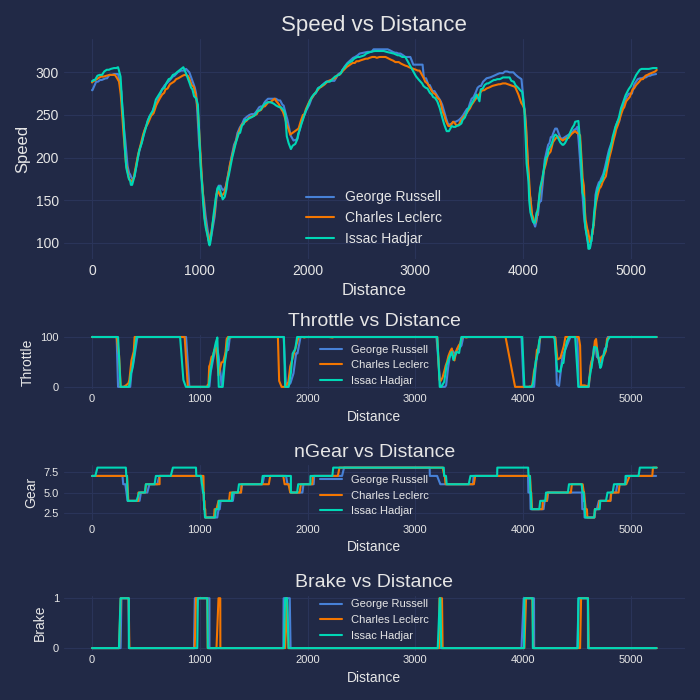

In [32]:
%matplotlib widget

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = quali.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_rus_quali.Distance, tele_rus_quali.Speed, label="George Russell", color=get_driver_color("VER")
)
ax[0].plot(
    tele_lec_quali.Distance, tele_lec_quali.Speed, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[0].plot(
    tele_had_quali.Distance, tele_had_quali.Speed, label="Issac Hadjar", color=get_driver_color("ANT")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_rus_quali.Distance, tele_rus_quali.Throttle, label="George Russell", color=get_driver_color("VER")
)
ax[1].plot(
    tele_lec_quali.Distance, tele_lec_quali.Throttle, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[1].plot(
    tele_had_quali.Distance, tele_had_quali.Throttle, label="Issac Hadjar", color=get_driver_color("ANT")
)


ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_rus_quali.Distance, tele_rus_quali.nGear, label="George Russell", color=get_driver_color("VER")
)
ax[2].plot(
    tele_lec_quali.Distance, tele_lec_quali.nGear, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[2].plot(
    tele_had_quali.Distance, tele_had_quali.nGear, label="Issac Hadjar", color=get_driver_color("ANT")
)


ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_rus_quali.Distance, tele_rus_quali.Brake, label="George Russell", color=get_driver_color("VER")
)
ax[3].plot(
    tele_lec_quali.Distance, tele_lec_quali.Brake, label="Charles Leclerc", color=get_driver_color("NOR")
)
ax[3].plot(
    tele_had_quali.Distance, tele_had_quali.Brake, label="Issac Hadjar", color=get_driver_color("ANT")
)

ax[3].set_title("Brake vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

for axis in ax:
    mplcursors.cursor(axis.lines, hover=True)

plt.tight_layout()
plt.show()


In [33]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_quali_sec1),
        "Sector1Time": rus_quali_sec1,
        "Sector2Time": rus_quali_sec2,
        "Sector3Time": rus_quali_sec3,
        "Lap Time": rus_quali_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_quali_sec1),
        "Sector1Time": lec_quali_sec1,
        "Sector2Time": lec_quali_sec2,
        "Sector3Time": lec_quali_sec3,
        "Lap Time": lec_quali_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Issac Hadjar"] * len(had_quali_sec1),
        "Sector1Time": had_quali_sec1,
        "Sector2Time": had_quali_sec2,
        "Sector3Time": had_quali_sec3,
        "Lap Time": had_quali_lap_time,
    }
)




all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
0,George Russell,0 days 00:00:41.997000,0 days 00:00:19.351000,0 days 00:00:50.528000,0 days 00:01:51.876000
1,George Russell,0 days 00:00:27.990000,0 days 00:00:17.599000,0 days 00:00:34.251000,0 days 00:01:19.840000
2,George Russell,0 days 00:00:40.873000,0 days 00:00:22.025000,0 days 00:00:58.671000,0 days 00:02:01.569000
4,George Russell,0 days 00:00:52.390000,0 days 00:00:19.564000,0 days 00:00:38.359000,0 days 00:01:50.313000
5,George Russell,0 days 00:00:31.116000,0 days 00:00:23.100000,0 days 00:00:39.030000,0 days 00:01:33.246000
6,George Russell,0 days 00:00:27.908000,0 days 00:00:17.413000,0 days 00:00:34.186000,0 days 00:01:19.507000
8,George Russell,0 days 00:01:01.667000,0 days 00:00:23.062000,0 days 00:00:54.519000,0 days 00:02:19.248000
9,George Russell,0 days 00:00:27.816000,0 days 00:00:17.287000,0 days 00:00:33.831000,0 days 00:01:18.934000
11,George Russell,0 days 00:00:48.833000,0 days 00:00:20.916000,0 days 00:00:38.905000,0 days 00:01:48.654000
12,George Russell,0 days 00:00:27.662000,0 days 00:00:17.426000,0 days 00:00:33.899000,0 days 00:01:18.987000


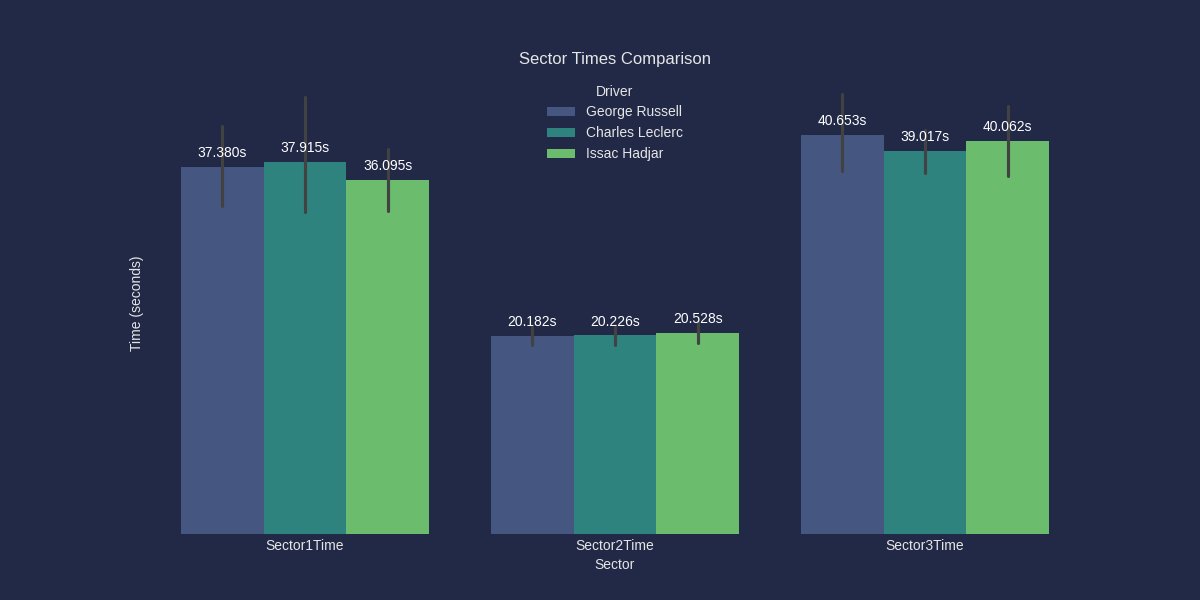

In [34]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

## Race

In [3]:
race = f1.get_session(2026, "Australia", "Race")
race.load()

req         WARNING 	DEFAULT CACHE ENABLED! (759.01 MB) /home/hexa/.cache/fastf1
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core 

In [4]:
race.session_info

{'Meeting': {'Key': 1279,
  'Name': 'Australian Grand Prix',
  'OfficialName': 'FORMULA 1 QATAR AIRWAYS AUSTRALIAN GRAND PRIX 2026',
  'Location': 'Melbourne',
  'Number': 1,
  'Country': {'Key': 5, 'Code': 'AUS', 'Name': 'Australia'},
  'Circuit': {'Key': 10, 'ShortName': 'Melbourne'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11234,
 'Type': 'Race',
 'Name': 'Race',
 'StartDate': datetime.datetime(2026, 3, 8, 15, 0),
 'EndDate': datetime.datetime(2026, 3, 8, 17, 0),
 'GmtOffset': datetime.timedelta(seconds=39600),
 'Path': '2026/2026-03-08_Australian_Grand_Prix/2026-03-08_Race/'}

In [5]:
race.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
63,RUS,Mercedes,-1.0,1.0,0 days 01:23:06.801000,Finished
12,ANT,Mercedes,-1.0,2.0,0 days 00:00:02.974000,Finished
16,LEC,Ferrari,-1.0,3.0,0 days 00:00:15.519000,Finished
44,HAM,Ferrari,-1.0,4.0,0 days 00:00:16.144000,Finished
1,NOR,McLaren,-1.0,5.0,0 days 00:00:51.741000,Finished
3,VER,Red Bull Racing,-1.0,6.0,0 days 00:00:54.617000,Finished
87,BEA,Haas F1 Team,-1.0,7.0,0 days 00:00:04.593000,Lapped
41,LIN,Racing Bulls,-1.0,8.0,0 days 00:00:11.816000,Lapped
5,BOR,Audi,-1.0,9.0,0 days 00:00:12.775000,Lapped
10,GAS,Alpine,-1.0,10.0,0 days 00:00:29.027000,Lapped


In [6]:
race_laps = race.laps
race_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,0 days 02:19:49.241000,BEA,87,0 days 00:01:24.615000,53.0,2.0,NaT,NaT,0 days 00:00:29.699000,0 days 00:00:17.937000,...,True,Haas F1 Team,0 days 02:18:24.626000,2026-03-08 05:19:31.249,1,7.0,False,,False,True
1003,0 days 02:21:13.851000,BEA,87,0 days 00:01:24.610000,54.0,2.0,NaT,NaT,0 days 00:00:29.965000,0 days 00:00:17.876000,...,True,Haas F1 Team,0 days 02:19:49.241000,2026-03-08 05:20:55.864,1,7.0,False,,False,True
1004,0 days 02:22:38.351000,BEA,87,0 days 00:01:24.500000,55.0,2.0,NaT,NaT,0 days 00:00:29.725000,0 days 00:00:17.930000,...,True,Haas F1 Team,0 days 02:21:13.851000,2026-03-08 05:22:20.474,1,7.0,False,,False,True
1005,0 days 02:24:04.790000,BEA,87,0 days 00:01:26.439000,56.0,2.0,NaT,NaT,0 days 00:00:29.768000,0 days 00:00:17.858000,...,True,Haas F1 Team,0 days 02:22:38.351000,2026-03-08 05:23:44.974,1,7.0,False,,False,True


In [ ]:
rus_race_laps = race.laps.pick_driver("RUS")
fastest_lap_rus_race = rus_race_laps.pick_fastest().LapTime
rus_race_lap_time = rus_race_laps["LapTime"]
rus_race_sec1 = rus_race_laps["Sector1Time"]
rus_race_sec2 = rus_race_laps["Sector2Time"]
rus_race_sec3 = rus_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_rus_race), "which was in Lap number" ,rus_race_laps.pick_fastest().LapNumber)
rus_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:22.670000 which was in Lap number 21.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
876,0 days 00:01:32.694000,NaT,0 days 00:00:18.344000,0 days 00:00:36.548000,240.0,288.0,291.0,234.0
877,0 days 00:01:25.007000,0 days 00:00:29.753000,0 days 00:00:17.841000,0 days 00:00:37.413000,259.0,273.0,290.0,273.0
878,0 days 00:01:26.444000,0 days 00:00:29.845000,0 days 00:00:18.533000,0 days 00:00:38.066000,269.0,289.0,286.0,264.0
879,0 days 00:01:24.789000,0 days 00:00:29.949000,0 days 00:00:17.802000,0 days 00:00:37.038000,269.0,286.0,298.0,271.0
880,0 days 00:01:24.017000,0 days 00:00:29.636000,0 days 00:00:17.848000,0 days 00:00:36.533000,264.0,305.0,296.0,291.0


In [8]:
fastest_lap_rus_race = rus_race_laps.pick_fastest()
tele_rus_race = fastest_lap_rus_race.get_telemetry().add_distance()
speed_rus_race = tele_rus_race.Speed
tele_rus_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,295.164999,7,11321.000000
3,295.937500,7,11321.000000
4,297.137500,7,11321.000000
5,298.000000,7,11321.000000
6,299.708333,7,11321.000000
...,...,...,...
627,287.000000,7,11386.000000
628,287.000000,7,11386.000000
629,287.000000,7,11386.000000
630,287.971958,7,11396.853531


In [9]:
lec_race_laps = race.laps.pick_driver("LEC")
fastest_lap_lec_race = lec_race_laps.pick_fastest().LapTime
lec_race_lap_time = lec_race_laps["LapTime"]
lec_race_sec1 = lec_race_laps["Sector1Time"]
lec_race_sec2 = lec_race_laps["Sector2Time"]
lec_race_sec3 = lec_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_lec_race), "which was in Lap number" ,lec_race_laps.pick_fastest().LapNumber)
lec_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:22.579000 which was in Lap number 38.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
250,0 days 00:01:31.929000,NaT,0 days 00:00:18.663000,0 days 00:00:36.681000,248.0,280.0,277.0,244.0
251,0 days 00:01:26.212000,0 days 00:00:30.116000,0 days 00:00:18.180000,0 days 00:00:37.916000,247.0,289.0,300.0,269.0
252,0 days 00:01:25.453000,0 days 00:00:30.141000,0 days 00:00:17.876000,0 days 00:00:37.436000,250.0,306.0,285.0,275.0
253,0 days 00:01:24.553000,0 days 00:00:29.990000,0 days 00:00:18.045000,0 days 00:00:36.518000,254.0,289.0,293.0,271.0
254,0 days 00:01:23.981000,0 days 00:00:29.542000,0 days 00:00:18.008000,0 days 00:00:36.431000,255.0,289.0,291.0,288.0


In [10]:
fastest_lap_lec_race = lec_race_laps.pick_fastest()
tele_lec_race = fastest_lap_lec_race.get_telemetry().add_distance()
speed_lec_race = tele_lec_race.Speed
tele_lec_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,303.587498,8,10646.603078
3,304.724998,8,10669.068718
4,307.000000,8,10714.000000
5,307.000000,8,10733.599974
6,307.000000,8,10746.000000
...,...,...,...
609,300.595000,7,10551.954964
610,301.000000,8,10507.000000
611,303.000000,8,10589.000000
612,303.990001,8,10616.720018


In [11]:
ver_race_laps = race.laps.pick_driver("VER")
fastest_lap_ver_race = ver_race_laps.pick_fastest().LapTime
ver_race_lap_time = ver_race_laps["LapTime"]
ver_race_sec1 = ver_race_laps["Sector1Time"]
ver_race_sec2 = ver_race_laps["Sector2Time"]
ver_race_sec3 = ver_race_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_ver_race), "which was in Lap number" ,ver_race_laps.pick_fastest().LapNumber)
ver_race_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:22.091000 which was in Lap number 43.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
409,0 days 00:01:41.333000,NaT,0 days 00:00:18.975000,0 days 00:00:39.753000,235.0,292.0,277.0,211.0
410,0 days 00:01:26.828000,0 days 00:00:31.200000,0 days 00:00:18.005000,0 days 00:00:37.623000,245.0,313.0,306.0,269.0
411,0 days 00:01:27.096000,0 days 00:00:31.213000,0 days 00:00:18.031000,0 days 00:00:37.852000,246.0,306.0,306.0,266.0
412,0 days 00:01:26.571000,0 days 00:00:30.547000,0 days 00:00:17.928000,0 days 00:00:38.096000,251.0,292.0,303.0,282.0
413,0 days 00:01:24.879000,0 days 00:00:29.902000,0 days 00:00:18.360000,0 days 00:00:36.617000,247.0,295.0,308.0,281.0


In [12]:
fastest_lap_ver_race = ver_race_laps.pick_fastest()
tele_ver_race = fastest_lap_ver_race.get_telemetry().add_distance()
speed_ver_race = tele_ver_race.Speed
tele_ver_race.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,294.989285,8,10549.903569
3,295.000000,8,10550.000000
4,296.000000,8,10589.000000
5,296.356250,8,10589.000000
6,297.000000,8,10589.000000
...,...,...,...
619,302.909374,8,10839.165595
620,304.596874,8,10922.978095
621,305.000000,8,10943.000000
622,306.407142,8,10963.403565


In [13]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_race_sec1),
        "Sector1Time": rus_race_sec1,
        "Sector2Time": rus_race_sec2,
        "Sector3Time": rus_race_sec3,
        "Lap Time": rus_race_lap_time,
    }
)

driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_race_sec1),
        "Sector1Time": lec_race_sec1,
        "Sector2Time": lec_race_sec2,
        "Sector3Time": lec_race_sec3,
        "Lap Time": lec_race_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_race_sec1),
        "Sector1Time": ver_race_sec1,
        "Sector2Time": ver_race_sec2,
        "Sector3Time": ver_race_sec3,
        "Lap Time": ver_race_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,George Russell,0 days 00:00:29.753000,0 days 00:00:17.841000,0 days 00:00:37.413000,0 days 00:01:25.007000
2,George Russell,0 days 00:00:29.845000,0 days 00:00:18.533000,0 days 00:00:38.066000,0 days 00:01:26.444000
3,George Russell,0 days 00:00:29.949000,0 days 00:00:17.802000,0 days 00:00:37.038000,0 days 00:01:24.789000
4,George Russell,0 days 00:00:29.636000,0 days 00:00:17.848000,0 days 00:00:36.533000,0 days 00:01:24.017000
5,George Russell,0 days 00:00:29.498000,0 days 00:00:17.709000,0 days 00:00:37.432000,0 days 00:01:24.639000
...,...,...,...,...,...
169,Max Verstappen,0 days 00:00:29.024000,0 days 00:00:17.803000,0 days 00:00:36.263000,0 days 00:01:23.090000
170,Max Verstappen,0 days 00:00:29.154000,0 days 00:00:17.844000,0 days 00:00:36.213000,0 days 00:01:23.211000
171,Max Verstappen,0 days 00:00:29.051000,0 days 00:00:17.734000,0 days 00:00:36.324000,0 days 00:01:23.109000
172,Max Verstappen,0 days 00:00:29.153000,0 days 00:00:17.830000,0 days 00:00:36.486000,0 days 00:01:23.469000


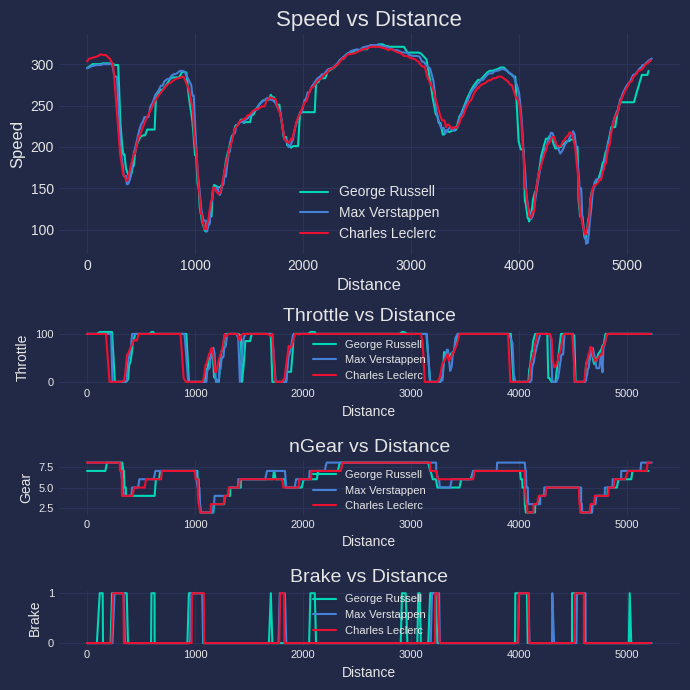

In [15]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = race.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_rus_race.Distance, tele_rus_race.Speed, label="George Russell", color=get_driver_color("RUS")
)
ax[0].plot(
    tele_ver_race.Distance, tele_ver_race.Speed, label="Max Verstappen", color=get_driver_color("VER")
)
ax[0].plot(
    tele_lec_race.Distance, tele_lec_race.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)

ax[1].plot(
    tele_rus_race.Distance, tele_rus_race.Throttle, label="George Russell", color=get_driver_color("RUS")
)
ax[1].plot(
    tele_ver_race.Distance, tele_ver_race.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)
ax[1].plot(
    tele_lec_race.Distance, tele_lec_race.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_rus_race.Distance, tele_rus_race.nGear, label="George Russell", color=get_driver_color("RUS")
)
ax[2].plot(
    tele_ver_race.Distance, tele_ver_race.nGear, label="Max Verstappen", color=get_driver_color("VER")
)
ax[2].plot(
    tele_lec_race.Distance, tele_lec_race.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_rus_race.Distance, tele_rus_race.Brake, label="George Russell", color=get_driver_color("RUS")
)
ax[3].plot(
    tele_ver_race.Distance, tele_ver_race.Brake, label="Max Verstappen", color=get_driver_color("VER")
)
ax[3].plot(
    tele_lec_race.Distance, tele_lec_race.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[3].set_title("Brake vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [16]:
driver2_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_race_sec1),
        "Sector1Time": rus_race_sec1,
        "Sector2Time": rus_race_sec2,
        "Sector3Time": rus_race_sec3,
        "Lap Time": rus_race_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(ver_race_sec1),
        "Sector1Time": ver_race_sec1,
        "Sector2Time": ver_race_sec2,
        "Sector3Time": ver_race_sec3,
        "Lap Time": ver_race_lap_time,
    }
)


driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Charles Leclerc"] * len(lec_race_sec1),
        "Sector1Time": lec_race_sec1,
        "Sector2Time": lec_race_sec2,
        "Sector3Time": lec_race_sec3,
        "Lap Time": lec_race_lap_time,
    }
)


all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Charles Leclerc,0 days 00:00:30.116000,0 days 00:00:18.180000,0 days 00:00:37.916000,0 days 00:01:26.212000
2,Charles Leclerc,0 days 00:00:30.141000,0 days 00:00:17.876000,0 days 00:00:37.436000,0 days 00:01:25.453000
3,Charles Leclerc,0 days 00:00:29.990000,0 days 00:00:18.045000,0 days 00:00:36.518000,0 days 00:01:24.553000
4,Charles Leclerc,0 days 00:00:29.542000,0 days 00:00:18.008000,0 days 00:00:36.431000,0 days 00:01:23.981000
5,Charles Leclerc,0 days 00:00:29.775000,0 days 00:00:18.075000,0 days 00:00:36.972000,0 days 00:01:24.822000
...,...,...,...,...,...
169,Max Verstappen,0 days 00:00:29.024000,0 days 00:00:17.803000,0 days 00:00:36.263000,0 days 00:01:23.090000
170,Max Verstappen,0 days 00:00:29.154000,0 days 00:00:17.844000,0 days 00:00:36.213000,0 days 00:01:23.211000
171,Max Verstappen,0 days 00:00:29.051000,0 days 00:00:17.734000,0 days 00:00:36.324000,0 days 00:01:23.109000
172,Max Verstappen,0 days 00:00:29.153000,0 days 00:00:17.830000,0 days 00:00:36.486000,0 days 00:01:23.469000


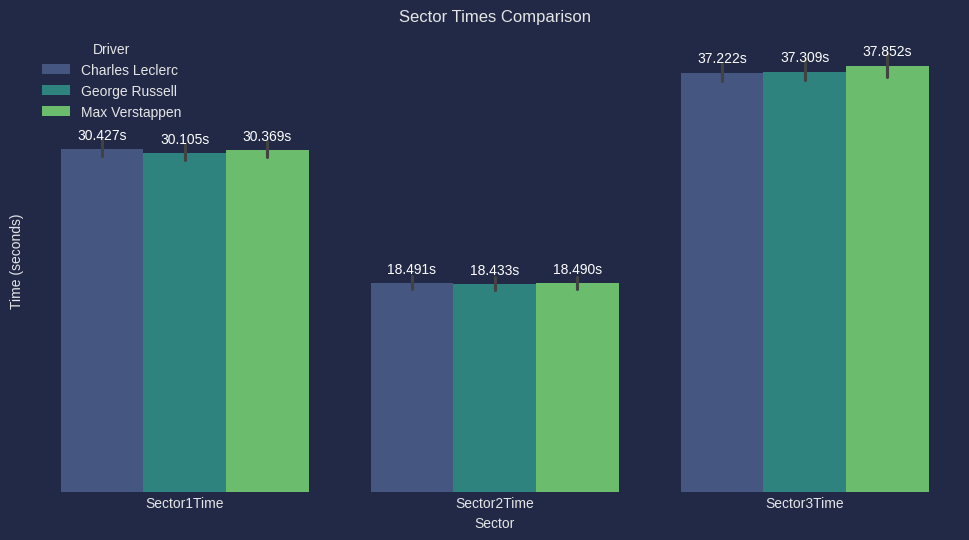

In [17]:
melted_data = all_drivers_sectors.melt(
    id_vars=["Driver"],
    value_vars=["Sector1Time", "Sector2Time", "Sector3Time"],
    var_name="Sector",
    value_name="Time",
)

melted_data["Time"] = melted_data["Time"].dt.total_seconds()

plt.figure(figsize=(12, 6))

bar_plot = sns.barplot(
    data=melted_data, x="Sector", y="Time", hue="Driver", palette="viridis"
)

for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        bar_plot.annotate(
            f"{height:.3f}s",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
        va="bottom",
            fontsize=10,
            color="white",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.title("Sector Times Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Sector")
plt.gca().set_yticks([])
plt.show()

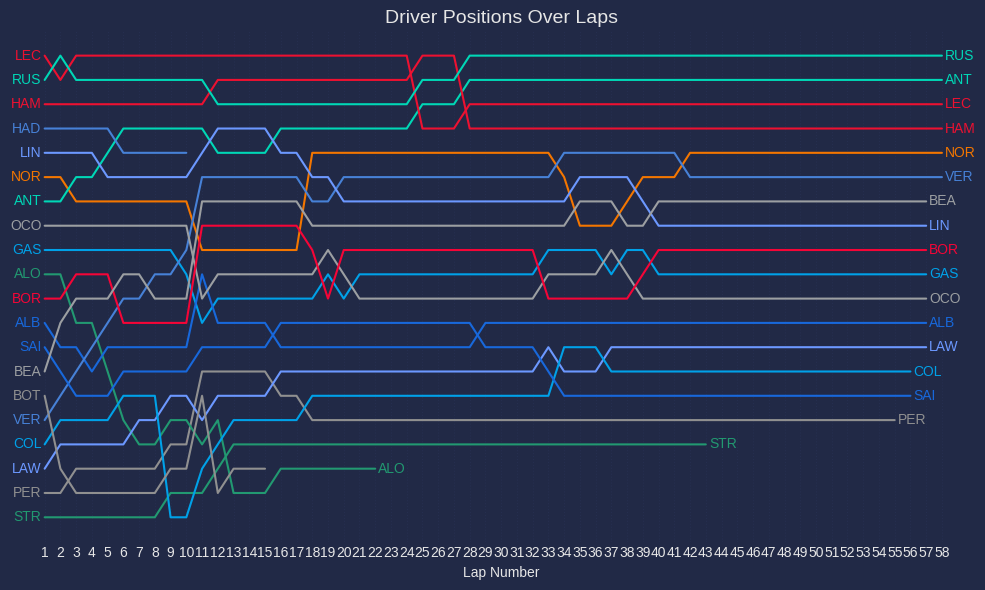

In [18]:
drivers = race.laps.Driver.unique()
drivers_ab = drivers.tolist()
nlaps = int(race.laps.LapNumber.unique().max())

team_colors = {}

for driver in drivers_ab:
    driver_object = race.get_driver(driver)
    hex_color = driver_object.TeamColor
    team_colors[driver] = hex_to_rgb(hex_color)

plt.figure(figsize=(10, 6))
for driver in drivers_ab:
    positions = race_laps[race_laps['Driver'] == driver]['Position'].values  
    color = team_colors.get(driver, (0.5, 0.5, 0.5))
    plt.plot(range(1, len(positions) + 1), positions, label=driver, color=color)
    
    plt.text(
        1 - 0.2,
        positions[0],
        driver,
        color=color,
        fontsize=10,
        verticalalignment='center',
        horizontalalignment='right'
    )
    
    plt.text(
        len(positions) + 0.2,
        positions[-1],
        driver,
        color=color,
        fontsize=10,
        verticalalignment='center',
        horizontalalignment='left'
    )

plt.title("Driver Positions Over Laps", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(0.5, float(nlaps) + 1.5)
plt.xlabel("Lap Number")
plt.ylim(0, 21)
plt.gca().invert_yaxis()
plt.gca().set_yticks([])
plt.xticks(range(1, nlaps + 1))
plt.tight_layout()
plt.show()

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.wa

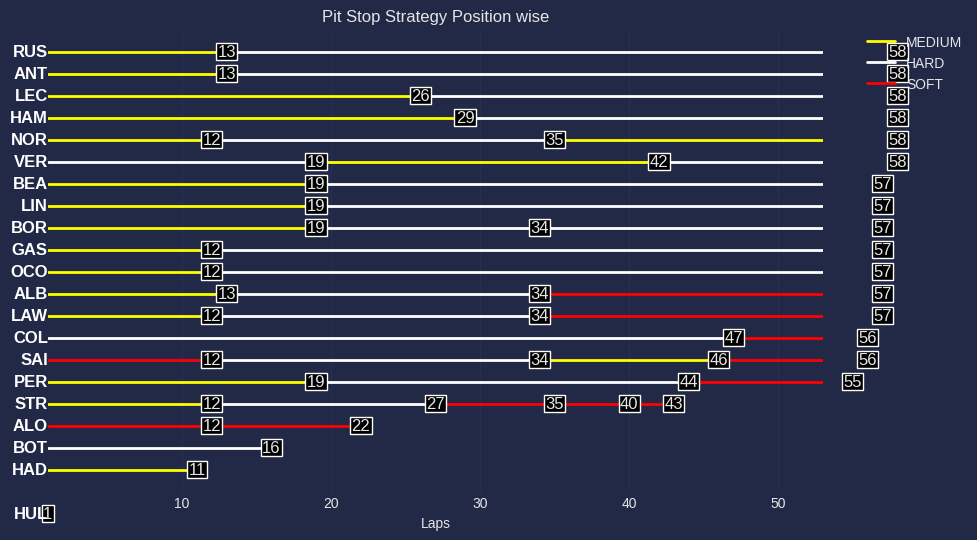

In [19]:
def getDriverPosition(abbreviation: str):
    res = race.results
    abbr = res["Abbreviation"] == abbreviation
    pos = res.loc[abbr, ["Position"]]
    posi = pos.iloc[-1]
    return int(posi.iloc[0])


def getCompound(abbreviation: str):
    driver_race = race.laps.pick_driver(abbreviation)
    lastLap = driver_race.LapNumber.count()
    if driver_race["TyreLife"].iloc[0] == 1.0:
        condition = driver_race["TyreLife"] == 1
        driver_comp = driver_race.loc[condition, ["Compound", "LapNumber"]]
        compound = driver_comp.Compound.tolist()
        return compound, driver_comp, lastLap
    else:
        compound = []
        result = []
        for i in range(0, len(driver_race["TyreLife"])):
            if driver_race["TyreLife"].iloc[i] < driver_race["TyreLife"].iloc[i - 1]:
                result.append(
                    {
                        "Compound": driver_race["Compound"].iloc[i],
                        "LapNumber": driver_race["LapNumber"].iloc[i],
                    }
                )
                compound.append(driver_race["Compound"].iloc[i])

        driver_comp = pd.DataFrame(result)
        return compound, driver_comp, lastLap


fig, ax = plt.subplots(figsize=(10, 6))

color_mapping = {
    "MEDIUM": "yellow",
    "SOFT": "red",
    "HARD": "white",
    "INTERMEDIATE": "green",
    "WET": "blue",
}
drivers = race.laps.Driver.unique()
drivers_ab = drivers.tolist()
used_labels = set()
for driver in drivers_ab:
    compound, driver_comp, lastLap = getCompound(driver)

    list1 = driver_comp.LapNumber.tolist()
    list1.append(lastLap)
    int_list = [int(x) for x in list1]
    x_points = int_list
    n = len(int_list)
    posi = getDriverPosition(driver)
    y_points = [posi] * n

    for i in range(len(driver_comp.LapNumber)):
        x_segment = [x_points[i], x_points[i + 1]]
        y_segment = [y_points[i], y_points[i + 1]]
        tire_color = color_mapping.get(compound[i], "#000000")
        label = compound[i] if compound[i] not in used_labels else None
        
        ax.plot(x_segment, y_segment, color=tire_color, linewidth=2, label=label)
        used_labels.add(compound[i])

        ax.text(
            x_points[i + 1],
            y_points[i + 1],
            str(x_points[i + 1]),
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(facecolor="black", edgecolor="white", pad=1),
        )
        ax.annotate(f'{i}',
                xy=(0, 1),
                xytext=(-10, 0),
                textcoords='offset points',
                va='center',
                ha='right',
                color="white",
                fontweight='bold')
    ax.text(
        x_points[0], 
        y_points[0], 
        driver, 
        fontsize=12, 
        ha='right', 
        va='center', 
        color="white", 
        fontweight='bold',
    )
    
ax.set_xlim(1, 53)
ax.invert_yaxis()
ax.set_ylim(21, 0)
ax.set_title("Pit Stop Strategy Position wise")
ax.set_xlabel("Laps")
plt.gca().set_yticks([])
ax.axvline(x=0, color='black', linewidth=2)
ax.grid(True, linestyle="-", alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.show()

In [20]:
res = race.results
drivers = res['Abbreviation'].tolist()
fastest_speed = pd.DataFrame(columns=['Driver', 'Speed'])
for i in drivers:
    tele = race.laps.pick_driver(i)
    speed = tele.SpeedST.max()
    df = pd.DataFrame({'Driver': [i], 'Speed': [speed]})
    fastest_speed = pd.concat([fastest_speed, df], ignore_index=True)
fastest_speed.sort_values(by="Speed",ascending=True)


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/tmp/ipykernel_20327/905247657.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fastest_speed = pd.concat([fastest_speed, df], ignore_index=True)


,Driver,Speed
17,ALO,289.0
11,ALB,291.0
18,BOT,291.0
4,NOR,297.0
12,LAW,297.0
15,PER,298.0
7,LIN,301.0
6,BEA,301.0
19,HAD,302.0
16,STR,302.0


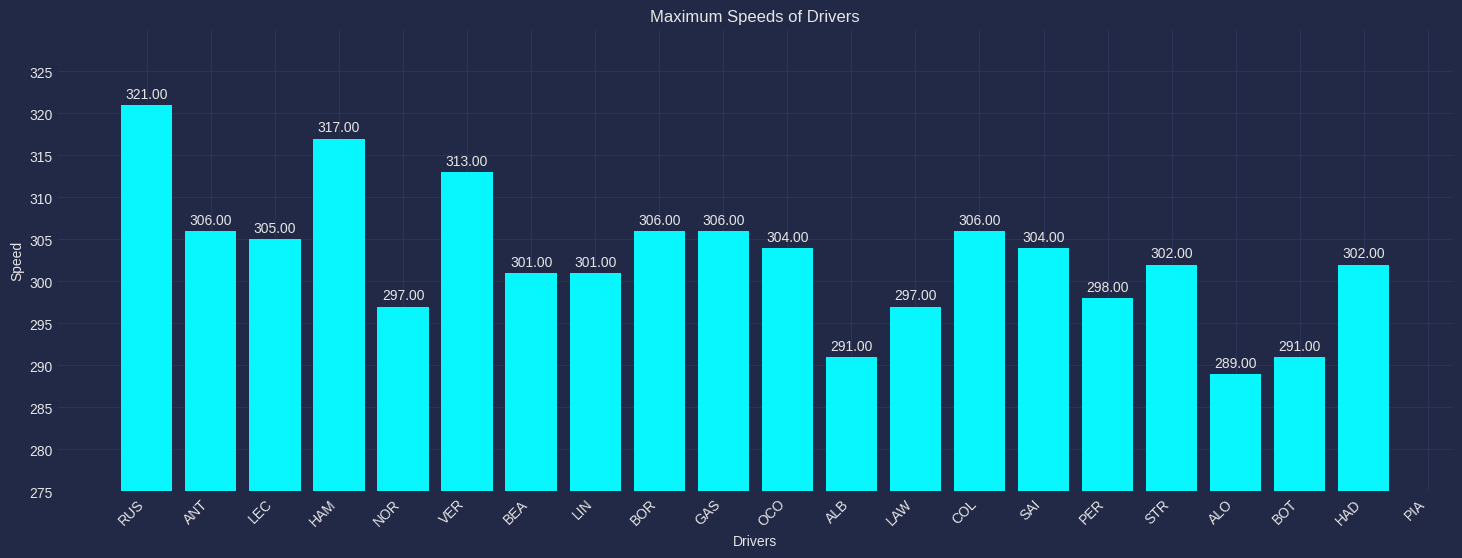

In [21]:
fig,ax = plt.subplots(figsize=(18, 6))
bars = ax.bar(fastest_speed['Driver'], fastest_speed['Speed'])
ax.set_xlabel('Drivers')
ax.set_ylabel('Speed')
ax.set_title('Maximum Speeds of Drivers')
plt.xticks(rotation=45, ha='right')

y_min = 275
y_max = np.ceil(fastest_speed['Speed'].max() / 5) * 5 + 5
y_ticks = np.arange(y_min, y_max, 5)
ax.set_ylim(y_min, y_max)
ax.set_yticks(y_ticks)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.2f}'.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()

In [22]:
plotting.setup_mpl()

In [24]:
laps_rus = race_laps.pick_driver("RUS")
laps_lec = race_laps.pick_driver("LEC")

fastest_rus = laps_rus.pick_fastest().get_telemetry().add_distance()
fastest_lec = laps_lec.pick_fastest().get_telemetry().add_distance()

fastest_rus["Driver"] = "RUS"
fastest_lec["Driver"] = "LEC"
telemetry = pd.concat([fastest_rus,fastest_lec])

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [25]:
num_minisectors = 25
total_distance = total_distance = max(telemetry['Distance'])
minisector_length = total_distance / num_minisectors
minisectors = [0]
for i in range(0, (num_minisectors - 1)):
    minisectors.append(minisector_length * (i + 1))
telemetry['Minisector'] = telemetry['Distance'].apply(
    lambda dist: (
        int((dist // minisector_length) + 1)
    )
)

In [26]:
average_speed = telemetry.groupby(['Minisector', 'Driver'])['Speed'].mean().reset_index()
average_speed

,Minisector,Driver,Speed
0,1,LEC,308.738853
1,1,RUS,299.551142
2,2,LEC,198.057727
3,2,RUS,218.628493
4,3,LEC,220.910498
5,3,RUS,207.232580
6,4,LEC,270.825149
7,4,RUS,273.540789
8,5,LEC,227.714133
9,5,RUS,229.890147


In [27]:
fastest_driver = average_speed.loc[average_speed.groupby(['Minisector'])['Speed'].idxmax()]

fastest_driver = fastest_driver[['Minisector', 'Driver']].rename(columns={'Driver': 'Fastest_driver'})


In [28]:
telemetry = telemetry.merge(fastest_driver, on=['Minisector'])

telemetry = telemetry.sort_values(by=['Distance'])

telemetry.loc[telemetry['Fastest_driver'] == 'RUS', 'Fastest_driver_int'] = 1
telemetry.loc[telemetry['Fastest_driver'] == 'LEC', 'Fastest_driver_int'] = 2

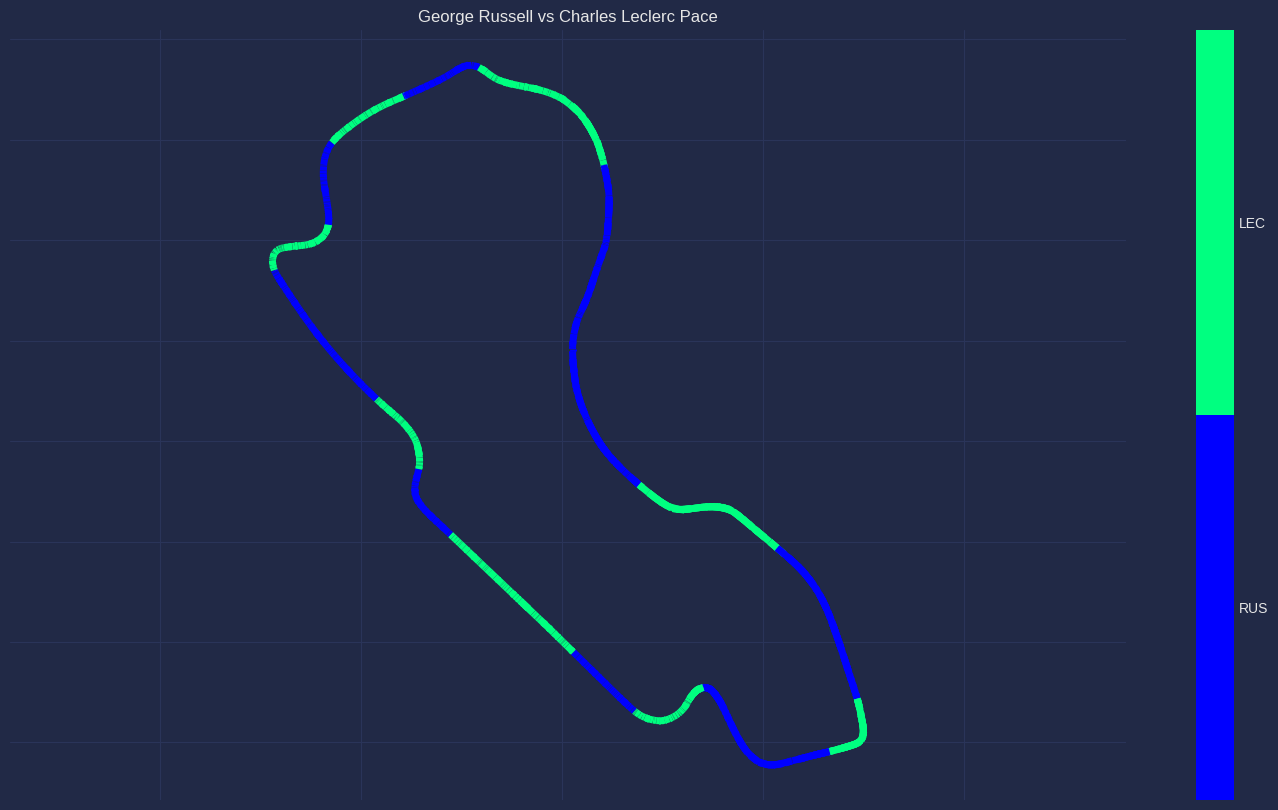

In [29]:
x = np.array(telemetry['X'].values)
y = np.array(telemetry['Y'].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
fastest_driver_array = telemetry['Fastest_driver_int'].to_numpy().astype(float)

cmap = plt.get_cmap('winter', 2)  # Create a colormap with 2 colors
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(fastest_driver_array)
lc_comp.set_linewidth(5)

plt.rcParams['figure.figsize'] = [18, 10]
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)

cbar = plt.colorbar(mappable=lc_comp, boundaries=[1, 2, 3])
cbar.set_ticks([1.5, 2.5])
cbar.set_ticklabels(['RUS', 'LEC'])
plt.title("George Russell vs Charles Leclerc Pace")
plt.show()


## Goerge vs Leclerc first lap fight


In [4]:
rus_race_laps = race.laps.pick_drivers("RUS")
first_lap_rus_race = rus_race_laps.pick_laps(1)
rus_race_lap_time = rus_race_laps["LapTime"]
rus_race_sec1 = rus_race_laps["Sector1Time"]
rus_race_sec2 = rus_race_laps["Sector2Time"]
rus_race_sec3 = rus_race_laps["Sector3Time"]
print("First Lap:", first_lap_rus_race)
# print("First Lap:", convert_to_normal(first_lap_rus_race), "which was in Lap number" ,rus_race_laps.pick_fastest().LapNumber)

First Lap:                       Time Driver DriverNumber                LapTime  \
876 0 days 01:03:52.673000    RUS           63 0 days 00:01:32.694000   

     LapNumber  Stint PitOutTime PitInTime Sector1Time            Sector2Time  \
876        1.0    1.0        NaT       NaT         NaT 0 days 00:00:18.344000   

     ... FreshTyre      Team           LapStartTime            LapStartDate  \
876  ...      True  Mercedes 0 days 01:02:19.743000 2026-03-08 04:03:26.366   

     TrackStatus  Position  Deleted  DeletedReason FastF1Generated IsAccurate  
876            1       2.0    False                          False      False  

[1 rows x 31 columns]


In [5]:
tele_rus_first_lap = first_lap_rus_race.get_telemetry().add_distance()
speed_rus_first_lap = tele_rus_first_lap.Speed
tele_rus_first_lap.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,0.000000,1,12429.518774
3,0.000000,1,12438.000000
4,0.000000,1,12352.000000
5,0.000000,1,12403.659948
6,0.000000,1,12434.000000
...,...,...,...
711,290.618751,7,11223.075018
712,292.118751,7,11245.075018
713,293.000000,7,11258.000000
714,293.000000,7,11279.862526


In [6]:
lec_race_laps = race.laps.pick_drivers("LEC")
first_lap_lec_race = lec_race_laps.pick_laps(1)
lec_race_lap_time = lec_race_laps["LapTime"]
lec_race_sec1 = lec_race_laps["Sector1Time"]
lec_race_sec2 = lec_race_laps["Sector2Time"]
lec_race_sec3 = lec_race_laps["Sector3Time"]
print("First Lap:", first_lap_lec_race)

First Lap:                       Time Driver DriverNumber                LapTime  \
250 0 days 01:03:51.908000    LEC           16 0 days 00:01:31.929000   

     LapNumber  Stint PitOutTime PitInTime Sector1Time            Sector2Time  \
250        1.0    1.0        NaT       NaT         NaT 0 days 00:00:18.663000   

     ... FreshTyre     Team           LapStartTime            LapStartDate  \
250  ...      True  Ferrari 0 days 01:02:19.743000 2026-03-08 04:03:26.366   

     TrackStatus  Position  Deleted  DeletedReason FastF1Generated IsAccurate  
250            1       1.0    False                          False      False  

[1 rows x 31 columns]


In [7]:
tele_lec_first_lap = first_lap_lec_race.get_telemetry().add_distance()
speed_lec_race = tele_lec_first_lap.Speed
tele_lec_first_lap.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,0.000000,1,11922.593868
3,0.000000,1,11965.000000
4,0.000000,1,11888.000000
5,0.000000,1,11888.000000
6,0.000000,1,11888.000000
...,...,...,...
704,278.503126,7,10939.509377
705,279.000000,7,10941.000000
706,279.000000,7,11005.000000
707,279.192858,7,11006.446432


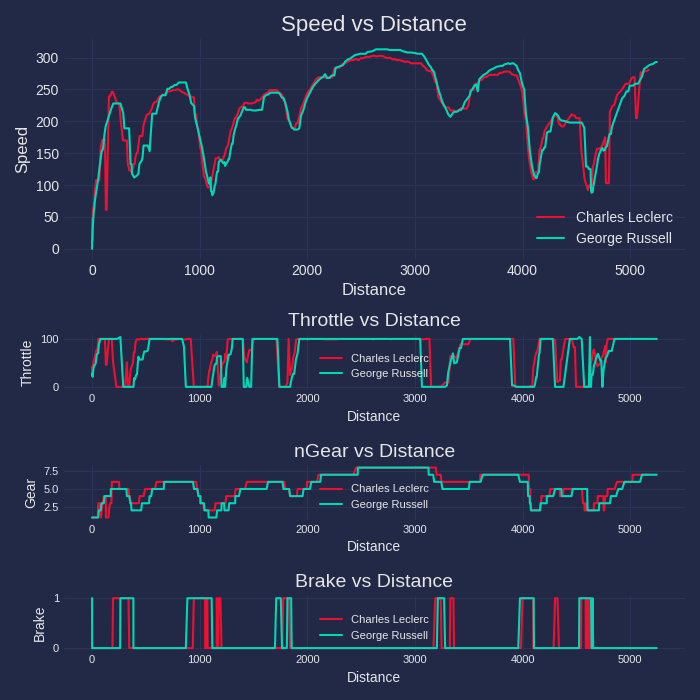

In [9]:
%matplotlib widget

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = race.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_lec_first_lap.Distance, tele_lec_first_lap.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[0].plot(
    tele_rus_first_lap.Distance, tele_rus_first_lap.Speed, label="George Russell", color=get_driver_color("RUS")
)


ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_lec_first_lap.Distance, tele_lec_first_lap.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[1].plot(
    tele_rus_first_lap.Distance, tele_rus_first_lap.Throttle, label="George Russell", color=get_driver_color("RUS")
)


ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_lec_first_lap.Distance, tele_lec_first_lap.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[2].plot(
    tele_rus_first_lap.Distance, tele_rus_first_lap.nGear, label="George Russell", color=get_driver_color("RUS")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_lec_first_lap.Distance, tele_lec_first_lap.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[3].plot(
    tele_rus_first_lap.Distance, tele_rus_first_lap.Brake, label="George Russell", color=get_driver_color("RUS")
)

ax[3].set_title("Brake vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()

for axis in ax:
    mplcursors.cursor(axis.lines, hover=True)

plt.show()


## Goerge vs Leclerc 8th lap fight


In [10]:
rus_race_laps = race.laps.pick_drivers("RUS")
eighth_lap_rus_race = rus_race_laps.pick_laps(8)
rus_race_lap_time = rus_race_laps["LapTime"]
rus_race_sec1 = rus_race_laps["Sector1Time"]
rus_race_sec2 = rus_race_laps["Sector2Time"]
rus_race_sec3 = rus_race_laps["Sector3Time"]
print("Eighth Lap:", eighth_lap_rus_race)
# print("First Lap:", convert_to_normal(first_lap_rus_race), "which was in Lap number" ,rus_race_laps.pick_fastest().LapNumber)

Eighth Lap:                       Time Driver DriverNumber                LapTime  \
883 0 days 01:13:46.858000    RUS           63 0 days 00:01:25.190000   

     LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
883        8.0    1.0        NaT       NaT 0 days 00:00:29.435000   

               Sector2Time  ... FreshTyre      Team           LapStartTime  \
883 0 days 00:00:18.391000  ...      True  Mercedes 0 days 01:12:21.668000   

               LapStartDate  TrackStatus  Position  Deleted  DeletedReason  \
883 2026-03-08 04:13:28.291            1       2.0    False                  

    FastF1Generated IsAccurate  
883           False       True  

[1 rows x 31 columns]


In [11]:
tele_rus_eighth_lap = eighth_lap_rus_race.get_telemetry().add_distance()
speed_rus_eighth_lap = tele_rus_eighth_lap.Speed
tele_rus_eighth_lap.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,309.692859,8,10705.857170
3,310.196428,8,10715.928558
4,311.000000,8,10732.000000
5,311.981310,8,10749.663573
6,314.000000,8,10786.000000
...,...,...,...
628,312.000000,8,10863.000000
629,315.062499,8,10975.546846
630,315.312502,8,10984.734463
631,316.000000,8,11010.000000


In [12]:
lec_race_laps = race.laps.pick_drivers("LEC")
eighth_lap_lec_race = lec_race_laps.pick_laps(8)
lec_race_lap_time = lec_race_laps["LapTime"]
lec_race_sec1 = lec_race_laps["Sector1Time"]
lec_race_sec2 = lec_race_laps["Sector2Time"]
lec_race_sec3 = lec_race_laps["Sector3Time"]
print("eighth Lap:", eighth_lap_lec_race)

eighth Lap:                       Time Driver DriverNumber                LapTime  \
257 0 days 01:13:46.526000    LEC           16 0 days 00:01:25.563000   

     LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
257        8.0    1.0        NaT       NaT 0 days 00:00:30.478000   

               Sector2Time  ... FreshTyre     Team           LapStartTime  \
257 0 days 00:00:18.017000  ...      True  Ferrari 0 days 01:12:20.963000   

               LapStartDate  TrackStatus  Position  Deleted  DeletedReason  \
257 2026-03-08 04:13:27.586            1       1.0    False                  

    FastF1Generated IsAccurate  
257           False       True  

[1 rows x 31 columns]


In [13]:
tele_lec_eighth_lap = eighth_lap_lec_race.get_telemetry().add_distance()
speed_lec_eighth_lap = tele_lec_eighth_lap.Speed
tele_lec_eighth_lap.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,295.993749,7,11126.000448
3,298.000000,7,10377.000000
4,298.656251,7,10483.312694
5,299.000000,8,10539.000000
6,301.000000,8,10539.000000
...,...,...,...
630,277.000000,7,10893.000000
631,277.000000,7,10893.984374
632,277.000000,7,10898.796879
633,277.000000,7,10900.000000


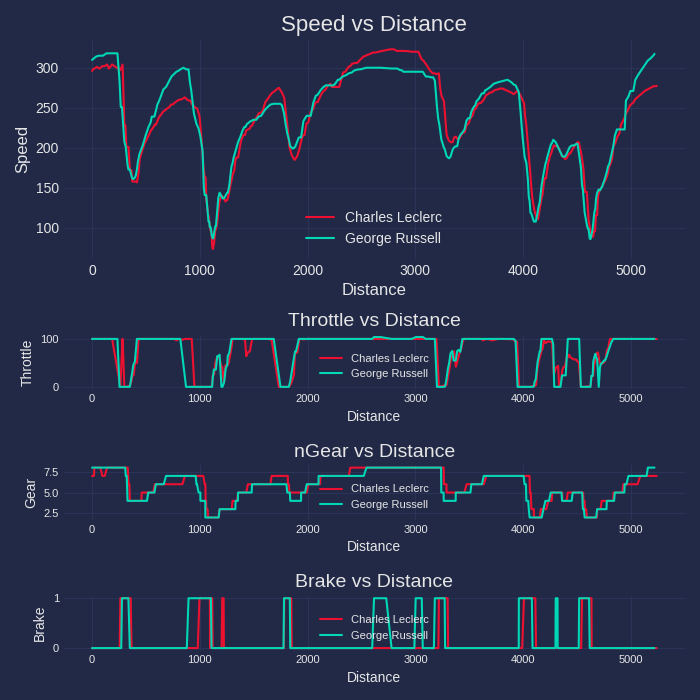

In [35]:
%matplotlib widget

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = race.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_lec_eighth_lap.Distance, tele_lec_eighth_lap.Speed, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[0].plot(
    tele_rus_eighth_lap.Distance, tele_rus_eighth_lap.Speed, label="George Russell", color=get_driver_color("RUS")
)


ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_lec_eighth_lap.Distance, tele_lec_eighth_lap.Throttle, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[1].plot(
    tele_rus_eighth_lap.Distance, tele_rus_eighth_lap.Throttle, label="George Russell", color=get_driver_color("RUS")
)


ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_lec_eighth_lap.Distance, tele_lec_eighth_lap.nGear, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[2].plot(
    tele_rus_eighth_lap.Distance, tele_rus_eighth_lap.nGear, label="George Russell", color=get_driver_color("RUS")
)

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_lec_eighth_lap.Distance, tele_lec_eighth_lap.Brake, label="Charles Leclerc", color=get_driver_color("LEC")
)
ax[3].plot(
    tele_rus_eighth_lap.Distance, tele_rus_eighth_lap.Brake, label="George Russell", color=get_driver_color("RUS")
)

ax[3].set_title("Brake vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()

for axis in ax:
    mplcursors.cursor(axis.lines, hover=True)

plt.show()
